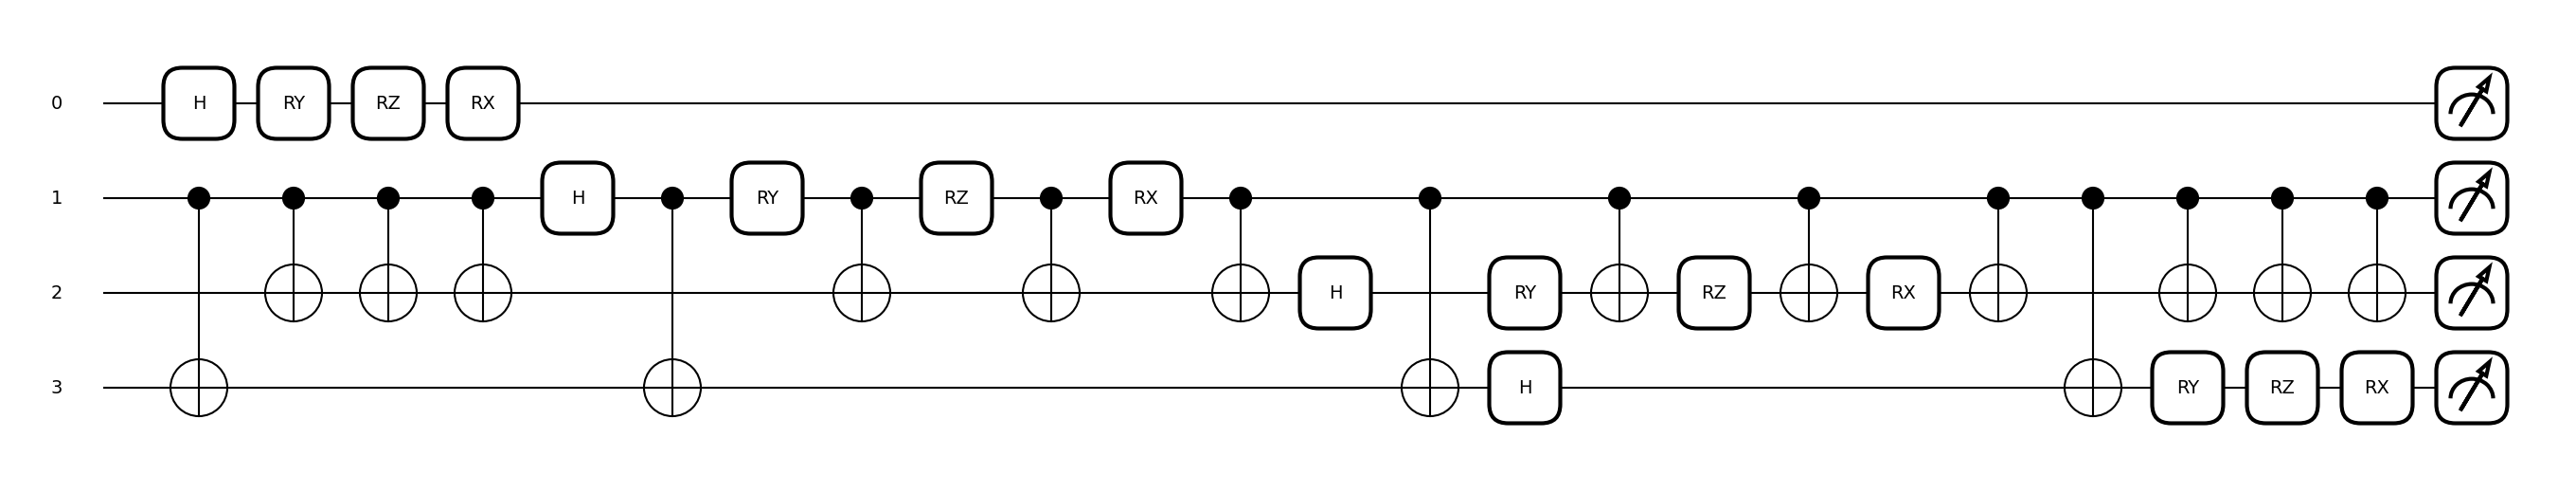

In [1]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR

df=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\1002-ORIGIN-2D electronic properties2.csv",encoding='ISO-8859–1')      
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]



# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x)

# Quantum setup
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[1, 3])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[1, 2])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [2]:
y_train=(y)

In [3]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(X_train_scaled)

# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)


,kernel,'precomputed'
,degree,3
,gamma,2.0881963569756823
,coef0,0.0
,tol,0.001
,C,977
,epsilon,0.07491851902055541
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


train r^2: 0.5890696213334888
train MAE 0.6241436787432603
train RMSE: 0.8846700974263229


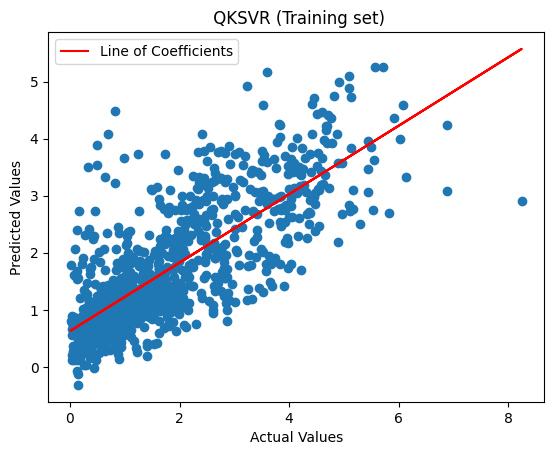

In [4]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_train,y_predtrain)), (-0.2, 20.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_train,y_predtrain)), (-0.2, 18.2))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (-0.2, 16.0))
plt.title(" QKSVR (Training set)")#title
plt.legend()

In [5]:
df_true50=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-50-EXTERNAL DATA.csv",encoding='ISO-8859–1')    
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y2 = df_true50['Band gap ']

# defining target
x2=df_true50[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test2= scaler.transform(x2)

# Compute the test kernel matrix (train-test kernel)
K_test2 = np.zeros((len(x_test2), len(X_train_scaled)))
for i in range(len(x_test2)):
    for j in range(len(X_train_scaled)):
        K_test2[i, j] = quantum_kernel(x_test2[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred2 = svr.predict(K_test2)
print("Predicted values:", y_pred2)

Predicted values: [1.19214094 0.99081331 0.71839365 1.18981678 1.43098309 1.21798463
 1.38072453 0.66127018 3.12388726 1.98715141 0.72708703 1.07622326
 1.72777734 0.29443764 0.92581538 0.17345972 1.35003514 0.78726566
 0.49579521 4.07598707 1.47920003 3.42101538 0.61443533 3.20774244
 1.19139953 1.30771649 1.06592436 0.74912072 2.42835359 2.84890141
 5.02961175 0.41161345 0.87950818 0.86506745 1.26167092 0.88170813
 0.05286313 3.51049081 4.38498101 0.99019681 3.15719475 1.71675667
 0.95235666 0.57231357 1.20821458 1.42311826 1.3145118  1.10712532
 0.4724361  4.01252233]


Model evaluation - Test Set:
r^2: 0.504914923962287
MAE 0.6018156215801593
RMSE: 0.8877914549370606


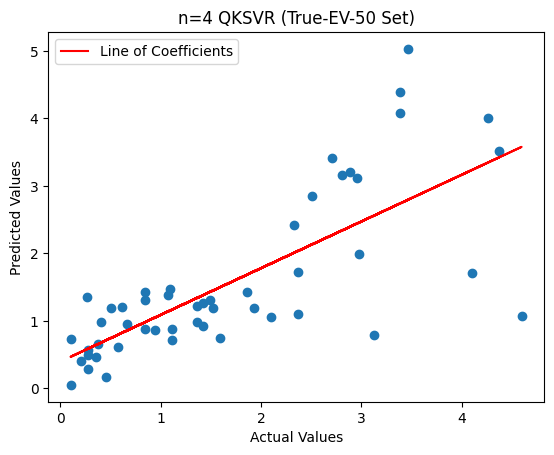

In [6]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y2, y_pred2))
print('MAE', mean_absolute_error(y2, y_pred2))
print('RMSE:',np.sqrt(mean_squared_error(y2, y_pred2)))
# Plot straight line
plt.scatter(y2, y_pred2)
coefficients = np.polyfit(y2, y_pred2, 1)
line = np.polyval(coefficients, y2)
plt.plot(y2, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y2, y_pred2)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y2, y_pred2))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y2, y_pred2)), (-0.2, 13.2))
plt.title("n=4 QKSVR (True-EV-50 Set)")#title
plt.legend()

In [7]:
df3=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-100-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y3 = df3['Band gap ']

# defining target
x3=df3[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test3= scaler.transform(x3)

# Compute the test kernel matrix (train-test kernel)
K_test3 = np.zeros((len(x_test3), len(X_train_scaled)))
for i in range(len(x_test3)):
    for j in range(len(X_train_scaled)):
        K_test3[i, j] = quantum_kernel(x_test3[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred3 = svr.predict(K_test3)
print("Predicted values:", y_pred3)

Predicted values: [0.96891708 3.68707582 1.47238876 1.30751834 4.92593993 1.53638857
 5.24959416 1.08355086 0.70133257 0.87439336 0.22469522 0.79157464
 0.70519835 0.07954897 1.16913405 2.4008001  1.24543486 0.92700057
 4.07332141 3.0783475  3.15078682 1.13224822 0.92202308 2.91105495
 1.04337674 2.01279825 3.17016509 3.38907317 1.42158646 1.97913313
 1.65068155 3.46507475 2.41402308 1.91165672 2.3772251  0.25025671
 0.9792813  0.90629108 1.27655486 1.79089546 2.20045169 1.15697554
 0.68671308 1.16400425 1.89876482 1.68067836 1.87726974 0.63879281
 0.96311192 1.06724729 0.05702356 1.09344789 0.37232111 0.84936502
 0.20410811 1.14720519 3.37826942 0.97951287 0.9278141  3.26539548
 3.00305286 1.29736163 1.08533809 1.73287191 0.54045082 1.41247279
 3.23391105 1.90739464 2.79391536 4.57732328 0.78527453 3.08322195
 0.88948441 1.28670104 0.97656227 4.53138886 2.79154404 0.87153031
 1.01772849 1.02936852 0.4548675  0.68515194 0.22820381 1.15598192
 0.98456375 0.54270007 2.79004501 1.08544394

Model evaluation - Test Set:
r^2: 0.649046449899493
MAE 0.6469962722180221
RMSE: 0.9395042286386157


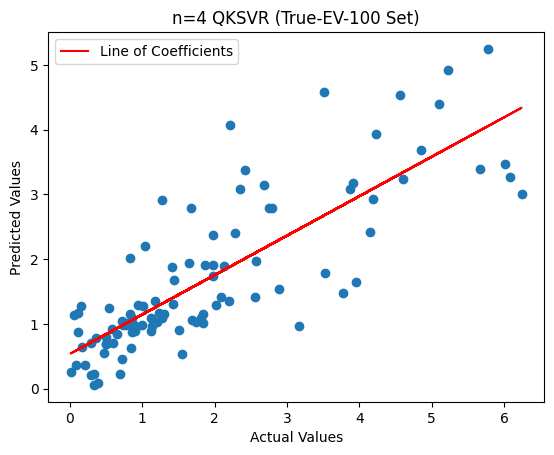

In [8]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y3, y_pred3))
print('MAE', mean_absolute_error(y3, y_pred3))
print('RMSE:',np.sqrt(mean_squared_error(y3, y_pred3)))
# Plot straight line
plt.scatter(y3, y_pred3)
coefficients = np.polyfit(y3, y_pred3, 1)
line = np.polyval(coefficients, y3)
plt.plot(y3, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y3, y_pred3)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y3, y_pred3))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y3, y_pred3)), (-0.2, 13.2))
plt.title("n=4 QKSVR (True-EV-100 Set)")#title
plt.legend()

In [9]:

df4=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-250-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y4 = df4['Band gap ']

# defining target
x4=df4[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test4= scaler.transform(x4)

# Compute the test kernel matrix (train-test kernel)
K_test4 = np.zeros((len(x_test4), len(X_train_scaled)))
for i in range(len(x_test4)):
    for j in range(len(X_train_scaled)):
        K_test4[i, j] = quantum_kernel(x_test4[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred4 = svr.predict(K_test4)
print("Predicted values:", y_pred4)

Predicted values: [1.51898847 3.82797569 1.17730974 1.16693854 1.31191643 1.23059671
 2.12884051 0.75506742 0.68234269 5.09098031 0.76119985 4.62110569
 1.12727467 0.5262322  0.42484902 0.87457791 3.56185075 0.87756391
 1.07619126 1.18508726 3.92599858 1.13154902 3.12412032 1.18168562
 1.69017948 1.53693519 2.7057607  1.30561499 2.58481179 2.02662195
 0.94063894 1.01844772 1.54195708 0.85448777 2.19879869 1.25543514
 0.94072378 1.04489819 1.70045968 2.02320967 0.73111135 0.86194788
 0.91665899 1.25840036 1.59736238 3.78960675 0.75779502 1.14159127
 1.84289206 0.63325532 0.30467447 2.04928145 0.10694185 0.9526986
 0.88961884 4.63089209 0.69666142 1.43627537 1.31561172 1.54092689
 3.1881024  1.20632153 1.97221747 0.16041414 0.89295579 2.3362252
 0.94157304 0.85318279 2.6454283  1.35225722 0.78312786 3.9476616
 2.02652352 0.89900542 0.35158598 1.06681608 0.57198158 1.00852386
 0.80654155 1.04872763 1.15690099 0.07168582 1.57240766 3.50028877
 1.93696597 1.80303716 1.75987952 3.72155466 0.

Model evaluation - Test Set:
r^2: 0.5582260677421371
MAE 0.6468224031436635
RMSE: 0.9723192965994125


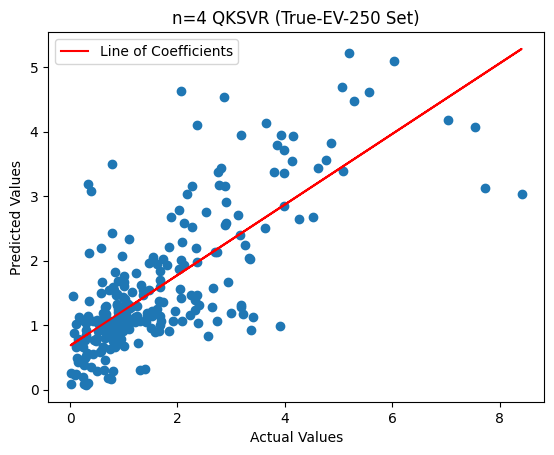

In [10]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y4, y_pred4))
print('MAE', mean_absolute_error(y4, y_pred4))
print('RMSE:',np.sqrt(mean_squared_error(y4, y_pred4)))
# Plot straight line
plt.scatter(y4, y_pred4)
coefficients = np.polyfit(y4, y_pred4, 1)
line = np.polyval(coefficients, y4)
plt.plot(y4, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y4, y_pred4)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y4, y_pred4))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y4, y_pred4)), (-0.2, 13.2))
plt.title("n=4 QKSVR (True-EV-250 Set)")#title
plt.legend()

In [11]:
df5=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-400-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y5 = df5['Band gap ']

# defining target
x5=df5[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test5= scaler.transform(x5)

# Compute the test kernel matrix (train-test kernel)
K_test5 = np.zeros((len(x_test5), len(X_train_scaled)))
for i in range(len(x_test5)):
    for j in range(len(X_train_scaled)):
        K_test5[i, j] = quantum_kernel(x_test5[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred5 = svr.predict(K_test5)
print("Predicted values:", y_pred5)

Predicted values: [1.19214094 0.99081331 0.71839365 1.18981678 1.43098309 1.21798463
 1.38072453 0.66127018 3.12388726 1.98715141 0.72708703 1.07622326
 1.72777734 0.29443764 0.92581538 0.17345972 1.35003514 0.78726566
 0.49579521 4.07598707 1.47920003 3.42101538 0.61443533 3.20774244
 1.19139953 1.30771649 1.06592436 0.74912072 2.42835359 2.84890141
 5.02961175 0.41161345 0.87950818 0.86506745 1.26167092 0.88170813
 0.05286313 3.51049081 4.38498101 0.99019681 3.15719475 1.71675667
 0.95235666 0.57231357 1.20821458 1.42311826 1.3145118  1.10712532
 0.4724361  4.01252233 0.96891708 3.68707582 1.47238876 1.30751834
 4.92593993 1.53638857 5.24959416 1.08355086 0.70133257 0.87439336
 0.22469522 0.79157464 0.70519835 0.07954897 1.16913405 2.4008001
 1.24543486 0.92700057 4.07332141 3.0783475  3.15078682 1.13224822
 0.92202308 2.91105495 1.04337674 2.01279825 3.17016509 3.38907317
 1.42158646 1.97913313 1.65068155 3.46507475 2.41402308 1.91165672
 2.3772251  0.25025671 0.9792813  0.90629108 

Model evaluation - Test Set:
r^2: 0.5815753985771301
MAE 0.641240022716815
RMSE: 0.953974195891641


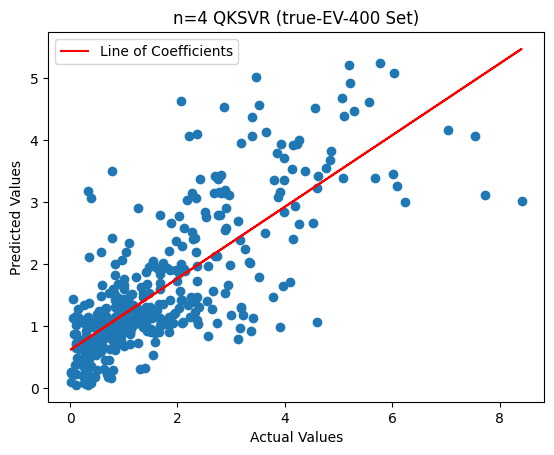

In [12]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y5, y_pred5))
print('MAE', mean_absolute_error(y5, y_pred5))
print('RMSE:',np.sqrt(mean_squared_error(y5, y_pred5)))
# Plot straight line
plt.scatter(y5, y_pred5)
coefficients = np.polyfit(y5, y_pred5, 1)
line = np.polyval(coefficients, y5)
plt.plot(y5, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y5, y_pred5)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y5, y_pred5))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y5, y_pred5)), (-0.2, 13.2))
plt.title("n=4 QKSVR (true-EV-400 Set)")#title
plt.legend()